SUPRIYA K 
24BAD118
RMSE: 6.256885107908462
MAE: 3.467165025260962
movieId
1206    3.440406
924     3.393962
858     3.387983
1193    3.359867
2657    3.274858
Name: 1, dtype: float64


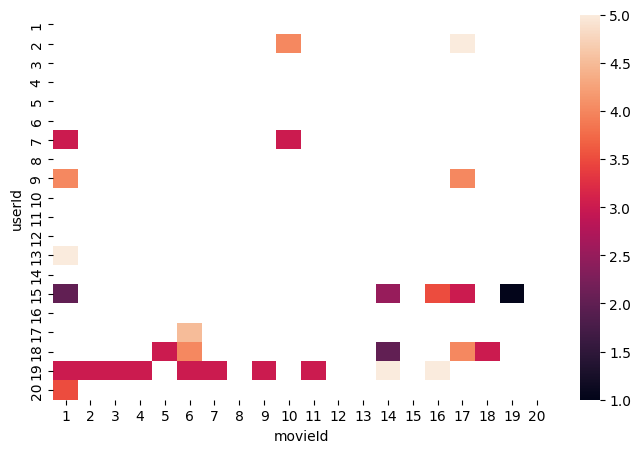

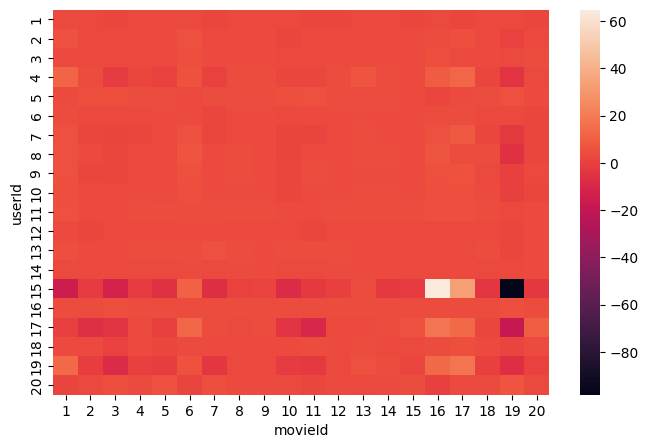

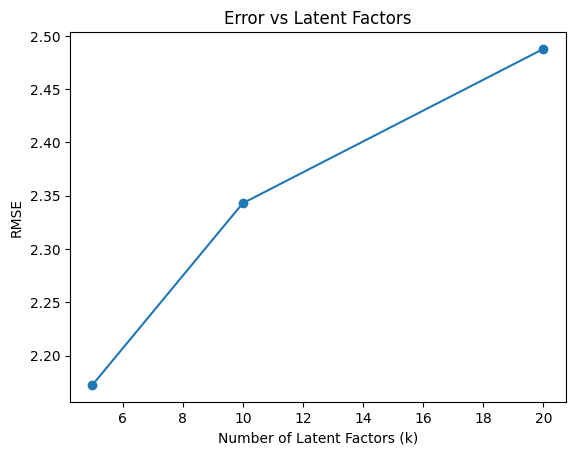

In [4]:
print("SUPRIYA K \n24BAD118")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
from math import sqrt

ratings = pd.read_csv("ratings.csv")

ratings = ratings[['userId','movieId','rating']]

train, test = train_test_split(ratings, test_size=0.2, random_state=42)

user_item_matrix = train.pivot(index='userId', columns='movieId', values='rating')

user_mean = user_item_matrix.mean(axis=1)

matrix_norm = user_item_matrix.sub(user_mean, axis=0)
matrix_norm = matrix_norm.fillna(0)

k = 20

svd = TruncatedSVD(n_components=k)

U = svd.fit_transform(matrix_norm)
Sigma = np.diag(svd.singular_values_)
Vt = svd.components_

reconstructed_matrix = np.dot(np.dot(U, Sigma), Vt)

reconstructed_matrix = pd.DataFrame(
    reconstructed_matrix,
    index=user_item_matrix.index,
    columns=user_item_matrix.columns
)

reconstructed_matrix = reconstructed_matrix.add(user_mean, axis=0)

y_true = []
y_pred = []

for row in test.itertuples():
    user = row.userId
    movie = row.movieId
    rating = row.rating
    
    if user in reconstructed_matrix.index and movie in reconstructed_matrix.columns:
        pred = reconstructed_matrix.loc[user, movie]
        y_true.append(rating)
        y_pred.append(pred)

rmse = sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)

print("RMSE:", rmse)
print("MAE:", mae)

def recommend_movies(user_id, n=5):
    user_ratings = reconstructed_matrix.loc[user_id]
    already_rated = user_item_matrix.loc[user_id].dropna().index
    recommendations = user_ratings.drop(already_rated)
    return recommendations.sort_values(ascending=False).head(n)

print(recommend_movies(1))

plt.figure(figsize=(8,5))
sns.heatmap(user_item_matrix.iloc[:20,:20])
plt.show()

plt.figure(figsize=(8,5))
sns.heatmap(reconstructed_matrix.iloc[:20,:20])
plt.show()

k_values = [5,10,20]
errors = []

for k in k_values:
    svd = TruncatedSVD(n_components=k)
    
    U = svd.fit_transform(matrix_norm)
    Sigma = np.diag(svd.singular_values_)
    Vt = svd.components_
    
    recon = np.dot(np.dot(U, Sigma), Vt)
    
    error = sqrt(mean_squared_error(matrix_norm.values.flatten(),
                                    recon.flatten()))
    
    errors.append(error)

plt.plot(k_values, errors, marker='o')
plt.xlabel("Number of Latent Factors (k)")
plt.ylabel("RMSE")
plt.title("Error vs Latent Factors")
plt.show()

SUPRIYA K 
24BAD118


C:\Users\supri\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\decomposition\_nmf.py:1728: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


RMSE: 3.075509969888776
movieId
912     0.144820
923     0.135218
908     0.124858
1247    0.120626
1225    0.119006
Name: 1, dtype: float64


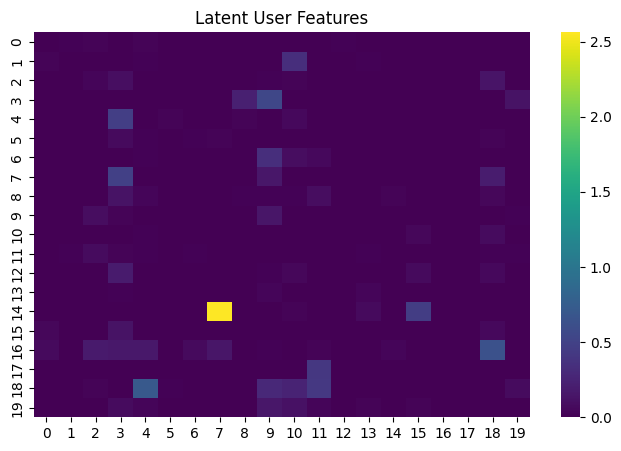

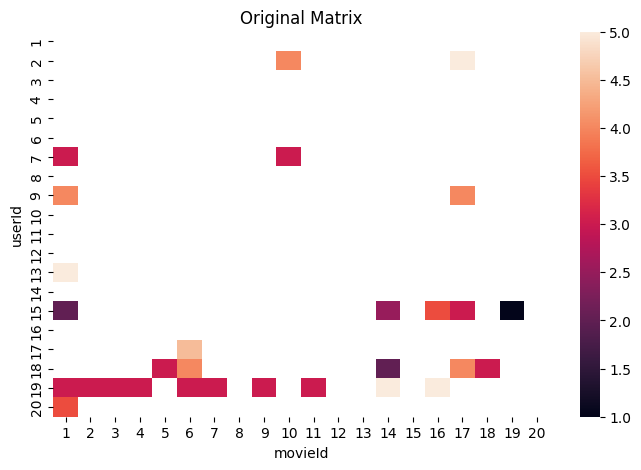

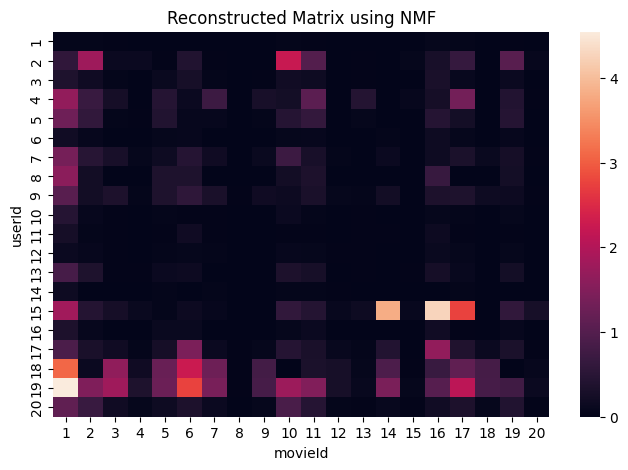

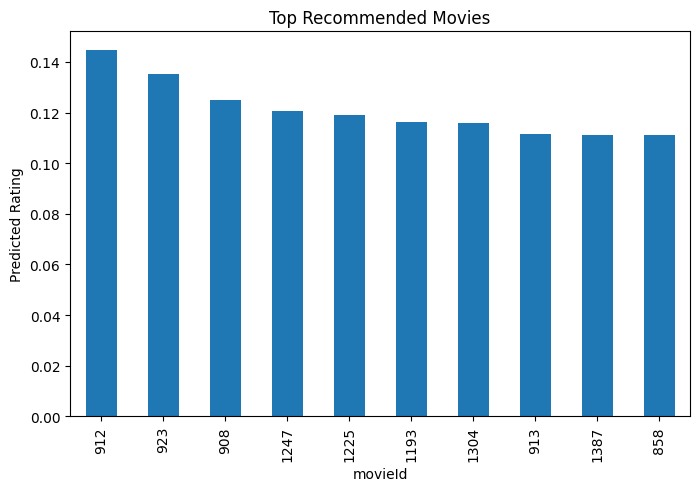

In [7]:
print("SUPRIYA K \n24BAD118")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import NMF
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from math import sqrt

ratings = pd.read_csv("ratings.csv")

ratings = ratings[['userId','movieId','rating']]

train, test = train_test_split(ratings, test_size=0.2, random_state=42)

user_item_matrix = train.pivot(index='userId', columns='movieId', values='rating')

user_item_filled = user_item_matrix.fillna(0)

nmf_model = NMF(n_components=20, init='random', random_state=42)

W = nmf_model.fit_transform(user_item_filled)
H = nmf_model.components_

nmf_reconstructed = np.dot(W, H)

nmf_reconstructed = pd.DataFrame(
    nmf_reconstructed,
    index=user_item_matrix.index,
    columns=user_item_matrix.columns
)

y_true = []
y_pred = []

for row in test.itertuples():
    user = row.userId
    movie = row.movieId
    rating = row.rating
    
    if user in nmf_reconstructed.index and movie in nmf_reconstructed.columns:
        pred = nmf_reconstructed.loc[user, movie]
        y_true.append(rating)
        y_pred.append(pred)

rmse = sqrt(mean_squared_error(y_true, y_pred))

print("RMSE:", rmse)

def recommend_movies(user_id, n=5):
    user_ratings = nmf_reconstructed.loc[user_id]
    already_rated = user_item_matrix.loc[user_id].dropna().index
    recommendations = user_ratings.drop(already_rated)
    return recommendations.sort_values(ascending=False).head(n)

print(recommend_movies(1))

plt.figure(figsize=(8,5))
sns.heatmap(W[:20], cmap="viridis")
plt.title("Latent User Features")
plt.show()

plt.figure(figsize=(8,5))
sns.heatmap(user_item_matrix.iloc[:20,:20])
plt.title("Original Matrix")
plt.show()

plt.figure(figsize=(8,5))
sns.heatmap(nmf_reconstructed.iloc[:20,:20])
plt.title("Reconstructed Matrix using NMF")
plt.show()

top_movies = recommend_movies(1,10)

plt.figure(figsize=(8,5))
top_movies.plot(kind='bar')
plt.title("Top Recommended Movies")
plt.ylabel("Predicted Rating")
plt.show()